# Multi-Agent Path Finding (MAPF) con PuLP — versión corregida

Varios robots deben desplazarse desde un nodo de origen hasta un nodo
destino dentro de una rejilla, evitando:

- Que dos robots ocupen el mismo nodo al mismo tiempo (capacidad).
- Que dos robots intercambien posiciones cruzando la misma arista en
  sentidos opuestos (swapping).
- Que un robot pierda continuidad en su recorrido (conservación de flujo).

Se formula como un MILP y se resuelve con PuLP, usando la variable
de decisión:

$$\rho^i_{a,b,k} \in \{0,1\}$$

In [1]:
!pip install pulp -q

In [2]:
import pulp
import matplotlib.pyplot as plt

## 1. Construcción de la red

Representamos el espacio donde se desplazan los robots mediante un grafo.
Cada celda de la rejilla corresponde a un nodo, y dos nodos son vecinos
cuando un robot puede desplazarse directamente entre ellos. Además de los
movimientos arriba/abajo/izquierda/derecha, se permite esperar en el mismo
nodo mediante un arco `(v,v)`.

In [3]:
FILAS = 5
COLUMNAS = 5

V = [(i, j) for i in range(FILAS) for j in range(COLUMNAS)]

E = []
for i, j in V:
    E.append(((i, j), (i, j)))  # esperar
    if i > 0:
        E.append(((i, j), (i - 1, j)))  # arriba
    if i < FILAS - 1:
        E.append(((i, j), (i + 1, j)))  # abajo
    if j > 0:
        E.append(((i, j), (i, j - 1)))  # izquierda
    if j < COLUMNAS - 1:
        E.append(((i, j), (i, j + 1)))  # derecha

print("Número de nodos:", len(V))
print("Número de aristas dirigidas:", len(E))

Número de nodos: 25
Número de aristas dirigidas: 105


## 2. Robots

Cada robot tiene un nodo de origen y un nodo destino. El modelo debe
encontrar una ruta para cada robot.

In [4]:
robots = {
    0: {"start": (0, 0), "goal": (4, 4)},
    1: {"start": (0, 4), "goal": (4, 0)},
    2: {"start": (4, 0), "goal": (0, 4)},
    3: {"start": (4, 4), "goal": (0, 0)},
}

R = list(robots.keys())
print("Robots:", R)
for r in R:
    print(f"Robot {r}: {robots[r]['start']} -> {robots[r]['goal']}")

Robots: [0, 1, 2, 3]
Robot 0: (0, 0) -> (4, 4)
Robot 1: (0, 4) -> (4, 0)
Robot 2: (4, 0) -> (0, 4)
Robot 3: (4, 4) -> (0, 0)


## 3. Horizonte temporal

Definimos un horizonte máximo `T`. Los robots pueden moverse durante como
máximo `T` instantes; si llegan antes, pueden esperar en su destino.

In [5]:
T = 20
K = range(1, T + 1)
print("Horizonte temporal:", T)

Horizonte temporal: 20


## 4. Variable de decisión

$$\rho^i_{a,b,k} \in \{0,1\}$$

Vale 1 si el robot $i$ utiliza la arista $(a,b)$ en el instante $k$.

In [6]:
rho = pulp.LpVariable.dicts("rho", (R, range(len(E)), K), cat=pulp.LpBinary)

## 5. Variable de makespan y modelo

$$\beta \geq 0, \qquad \min \beta$$

`beta` representa el instante máximo en el que los robots llegan a su
destino. También construimos aquí unos índices auxiliares que se usan en
varias restricciones más abajo.

In [7]:
beta = pulp.LpVariable("Beta", lowBound=0, cat=pulp.LpContinuous)

modelo = pulp.LpProblem("MAPF", pulp.LpMinimize)
modelo += beta

# Índices auxiliares (evitan recorrer E una y otra vez)
salidas_de = {v: [] for v in V}          # edges donde a == v
entradas_a = {v: [] for v in V}          # edges donde b == v (incluye self-loop)
entradas_reales_a = {v: [] for v in V}   # edges donde b == v y a != v (SIN self-loop)

for e_idx, (a, b) in enumerate(E):
    salidas_de[a].append(e_idx)
    entradas_a[b].append(e_idx)
    if a != b:
        entradas_reales_a[b].append(e_idx)

## 6. Posición inicial (Ajuste #1)

En el modelo original, la restricción de origen sumaba sobre **todos** los
`k`, lo que incluía la arista de espera `(a,a)`. Eso significa que "usar
una arista que sale del origen" (mover o esperar) solo podía pasar **una
vez en todo el horizonte**, así que el robot no podía esperar más de un
instante en su origen antes de partir.

Lo correcto es fijar la posición del robot en `k=1`: en ese instante, y
solo en ese instante, debe usar una arista que sale de su nodo de origen
(puede ser mover o esperar).

$$\sum_{b \in N:(s_i, b) \in E} \rho^i_{s_i, b, 1} = 1 \quad \forall i \in R$$

Restringe la salida del nodo origen $s_i$ exclusivamente al primer instante de tiempo, evitando bloqueos por esperas iniciales:

In [8]:
for i in R:
    origen = robots[i]["start"]
    modelo += (
        pulp.lpSum(rho[i][e_idx][1] for e_idx in salidas_de[origen]) == 1
    ), f"Inicio_robot_{i}"

## 7. Una sola arista activa por robot y por instante (Ajuste #2 - Bug principal)

Esta es la restricción que **faltaba por completo** en el modelo original.
Sin ella, nada impide que `rho^i_{a,b,k}` y `rho^i_{a',b',k}` valgan 1 al
mismo tiempo para aristas distintas: el robot "existe" simultáneamente en
dos movimientos distintos en el mismo instante `k`. Esto es justo lo que
producía las rutas que saltaban de un lado a otro del tablero sin ningún
sentido físico.

$$\sum_{e \in E} \rho^i_{e,k} = 1 \quad \forall i \in R, \, \forall k \in K$$

Obliga a que cada robot active exactamente una sola arista (ya sea moverse a un vecino o quedarse en su lugar con un self-loop) en cada instante $k$.

In [9]:
for i in R:
    for k in K:
        modelo += (
            pulp.lpSum(rho[i][e_idx][k] for e_idx in range(len(E))) == 1
        ), f"UnaAristaPorInstante_{i}_{k}"

## 8. Restricción de destino (Ajuste #3)

Igual que con el origen: la versión original contaba también la arista de
espera `(destino,destino)` como una "llegada". Como ahora obligamos a que
el robot tenga una arista activa en **todos** los instantes (punto 7), un
robot que llega antes de `T` necesariamente debe esperar en su destino
durante el resto del horizonte — y cada una de esas esperas volvía a
contar como una "llegada", violando la igualdad "=1" y dejando el modelo
infactible o forzando comportamientos absurdos.

La solución es excluir la arista de espera de la cuenta de "llegadas":
solo las aristas que realmente entran desde otro nodo cuentan como
llegada.

$$\sum_{k \in K} \sum_{a \in N : (a, g_i) \in E, \, a \neq g_i} \rho^i_{a, g_i, k} = 1 \quad \forall i \in R$$

Garantiza que el robot cuente su llegada al destino $g_i$ solo cuando entra desde un nodo distinto ($a \neq g_i$), ignorando los self-loops de espera posterior

In [10]:
for i in R:
    destino = robots[i]["goal"]
    modelo += (
        pulp.lpSum(
            rho[i][e_idx][k]
            for e_idx in entradas_reales_a[destino]
            for k in K
        )
        == 1
    ), f"Destino_robot_{i}"

## 9. Restricción de capacidad

Sin cambios respecto al original — aquí sí se debe incluir la arista de
espera: si un robot está esperando en un nodo, ese nodo sigue "ocupado" y
ningún otro robot puede entrar a él.

$$\sum_{i\in R}\sum_{a:(a,j)\in E}\rho^i_{a,j,k}\leq 1 \qquad \forall j\in V,\ \forall k$$

In [11]:
for j in V:
    for k in K:
        modelo += (
            pulp.lpSum(rho[i][e_idx][k] for i in R for e_idx in entradas_a[j])
            <= 1
        ), f"Capacidad_{j}_{k}"

## 10. Conservación de flujo

Sin cambios respecto al original.

$$\sum_{a:(a,j)\in E}\rho^i_{a,j,k} - \sum_{b:(j,b)\in E}\rho^i_{j,b,k+1} = 0$$

In [12]:
for i in R:
    for j in V:
        for k in range(1, T):
            modelo += (
                pulp.lpSum(rho[i][e_idx][k] for e_idx in entradas_a[j])
                - pulp.lpSum(rho[i][e_idx][k + 1] for e_idx in salidas_de[j])
                == 0
            ), f"Flujo_{i}_{j}_{k}"

## 11. Restricción de swapping

Sin cambios respecto al original — evita que dos robots crucen la misma
arista en sentidos opuestos al mismo tiempo.

$$
\sum_{i\in R}
\left(
\rho^i_{a,b,k}
+
\rho^i_{b,a,k}
\right)
\leq 1
$$

In [13]:
for a, b in E:
    if a == b:
        continue
    if (b, a) not in E:
        continue
    e_ab = E.index((a, b))
    e_ba = E.index((b, a))
    for k in K:
        modelo += (
            pulp.lpSum(rho[i][e_ab][k] + rho[i][e_ba][k] for i in R) <= 1
        ), f"Swap_{a}_{b}_{k}"

## 12. Makespan (Ajuste #4 — consistente con el ajuste #3)

Igual que en el punto 8: si aquí se sigue sumando sobre la arista de
espera del destino, `beta` terminaría reflejando el **último** instante en
que el robot "está" en su destino (potencialmente `T`, por las esperas) en
vez del instante real de **llegada**. Se usa el mismo conjunto de aristas
reales de entrada que en la restricción de destino.

$$\beta \ge k \cdot \sum_{a \in N : (a, g_i) \in E, \, a \neq g_i} \rho^i_{a, g_i, k} \quad \forall i \in R, \, \forall k \in K$$

In [14]:
for i in R:
    destino = robots[i]["goal"]
    modelo += (
        pulp.lpSum(
            k * rho[i][e_idx][k]
            for e_idx in entradas_reales_a[destino]
            for k in K
        )
        <= beta
    ), f"Makespan_robot_{i}"

## 13. Resolver el modelo

In [15]:
print("Número de variables:", len(modelo.variables()))
print("Número de restricciones:", len(modelo.constraints))

solver = pulp.PULP_CBC_CMD(msg=True)
modelo.solve(solver)

print("\nEstado:", pulp.LpStatus[modelo.status])
print("Makespan óptimo:", pulp.value(beta))

Número de variables: 8401
Número de restricciones: 4092

Estado: Optimal
Makespan óptimo: 8.0


## 14. Obtener las rutas

Recuperamos las variables $\rho$ que tienen valor 1 para reconstruir el
recorrido de cada robot.

In [16]:
rutas = {}
for i in R:
    movimientos = []
    for k in K:
        for e_idx, (a, b) in enumerate(E):
            valor = pulp.value(rho[i][e_idx][k])
            if valor is not None and valor > 0.5:
                movimientos.append((k, a, b))
    rutas[i] = movimientos

for i in R:
    print(f"\nRobot {i}")
    for k, a, b in rutas[i]:
        print(f"  t={k}: {a} -> {b}")


Robot 0
  t=1: (0, 0) -> (1, 0)
  t=2: (1, 0) -> (1, 1)
  t=3: (1, 1) -> (1, 2)
  t=4: (1, 2) -> (2, 2)
  t=5: (2, 2) -> (3, 2)
  t=6: (3, 2) -> (4, 2)
  t=7: (4, 2) -> (4, 3)
  t=8: (4, 3) -> (4, 4)
  t=9: (4, 4) -> (4, 4)
  t=10: (4, 4) -> (4, 4)
  t=11: (4, 4) -> (4, 4)
  t=12: (4, 4) -> (4, 4)
  t=13: (4, 4) -> (4, 4)
  t=14: (4, 4) -> (4, 4)
  t=15: (4, 4) -> (4, 4)
  t=16: (4, 4) -> (4, 4)
  t=17: (4, 4) -> (4, 4)
  t=18: (4, 4) -> (4, 4)
  t=19: (4, 4) -> (3, 4)
  t=20: (3, 4) -> (3, 4)

Robot 1
  t=1: (0, 4) -> (0, 3)
  t=2: (0, 3) -> (0, 2)
  t=3: (0, 2) -> (0, 1)
  t=4: (0, 1) -> (1, 1)
  t=5: (1, 1) -> (1, 0)
  t=6: (1, 0) -> (2, 0)
  t=7: (2, 0) -> (3, 0)
  t=8: (3, 0) -> (4, 0)
  t=9: (4, 0) -> (4, 0)
  t=10: (4, 0) -> (3, 0)
  t=11: (3, 0) -> (3, 0)
  t=12: (3, 0) -> (2, 0)
  t=13: (2, 0) -> (1, 0)
  t=14: (1, 0) -> (1, 0)
  t=15: (1, 0) -> (1, 0)
  t=16: (1, 0) -> (1, 0)
  t=17: (1, 0) -> (1, 0)
  t=18: (1, 0) -> (1, 0)
  t=19: (1, 0) -> (1, 0)
  t=20: (1, 0) -> (1, 0)


In [17]:
posiciones_por_robot = {}
for i in R:
    posiciones = [robots[i]["start"]]
    for k, a, b in rutas[i]:
        posiciones.append(b)
    posiciones_por_robot[i] = posiciones
    print(f"\nRobot {i}: {posiciones}")


Robot 0: [(0, 0), (1, 0), (1, 1), (1, 2), (2, 2), (3, 2), (4, 2), (4, 3), (4, 4), (4, 4), (4, 4), (4, 4), (4, 4), (4, 4), (4, 4), (4, 4), (4, 4), (4, 4), (4, 4), (3, 4), (3, 4)]

Robot 1: [(0, 4), (0, 3), (0, 2), (0, 1), (1, 1), (1, 0), (2, 0), (3, 0), (4, 0), (4, 0), (3, 0), (3, 0), (2, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0)]

Robot 2: [(4, 0), (3, 0), (2, 0), (1, 0), (0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 4), (0, 4), (0, 4), (0, 4), (0, 4), (0, 4), (0, 4), (0, 4), (0, 4), (0, 4), (0, 4), (0, 4)]

Robot 3: [(4, 4), (3, 4), (2, 4), (2, 3), (1, 3), (1, 2), (1, 1), (1, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0)]


## 15. Visualización

Representamos la rejilla y las rutas encontradas. Cada color corresponde a
un robot distinto.

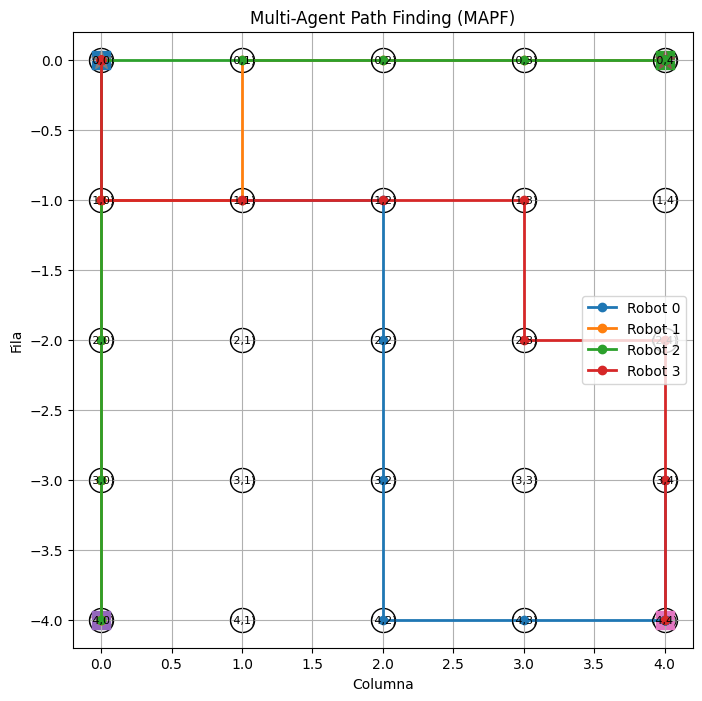

In [18]:
plt.figure(figsize=(8, 8))

for i in range(FILAS):
    for j in range(COLUMNAS):
        plt.scatter(j, -i, s=300, facecolors="white", edgecolors="black")
        plt.text(j, -i, f"({i},{j})", ha="center", va="center", fontsize=8)

for i in R:
    posiciones = posiciones_por_robot[i]
    x = [p[1] for p in posiciones]
    y = [-p[0] for p in posiciones]

    plt.plot(x, y, marker="o", linewidth=2, label=f"Robot {i}")

    s = robots[i]["start"]
    plt.scatter(s[1], -s[0], s=180, marker="s")

    g = robots[i]["goal"]
    plt.scatter(g[1], -g[0], s=200, marker="*")

plt.title("Multi-Agent Path Finding (MAPF)")
plt.xlabel("Columna")
plt.ylabel("Fila")
plt.grid(True)
plt.legend()
plt.show()

## 16. Animación del movimiento

En vez de ver solo el trazo final, es más claro ver a los robots moverse
paso a paso. Construimos una animación con `matplotlib.animation`: en cada
frame se dibuja la posición de cada robot en el instante `t`, junto con el
camino recorrido hasta ese momento. `to_jshtml()` la muestra como un
reproductor interactivo dentro del notebook (play/pausa/velocidad).

In [19]:
import matplotlib.animation as animation
from IPython.display import HTML

# Igualamos la longitud de todas las trayectorias por si algún robot
# llega antes que T (se queda "congelado" en su última posición)
T_max = max(len(posiciones_por_robot[i]) for i in R) - 1

trayectorias = {}
for i in R:
    pos = posiciones_por_robot[i]
    if len(pos) - 1 < T_max:
        pos = pos + [pos[-1]] * (T_max - (len(pos) - 1))
    trayectorias[i] = pos

fig, ax = plt.subplots(figsize=(7, 7))

for i in range(FILAS):
    for j in range(COLUMNAS):
        ax.scatter(j, -i, s=300, facecolors="white", edgecolors="black", zorder=1)

colores = plt.cm.tab10.colors

lineas = {}
puntos = {}
for idx, i in enumerate(R):
    color = colores[idx % len(colores)]
    (lineas[i],) = ax.plot([], [], linewidth=2, color=color, alpha=0.5, zorder=2)
    puntos[i] = ax.scatter([], [], s=250, color=color, zorder=3, label=f"Robot {i}")

    g = robots[i]["goal"]
    ax.scatter(g[1], -g[0], s=200, marker="*", color=color, zorder=2)

ax.set_xlim(-0.5, COLUMNAS - 0.5)
ax.set_ylim(-(FILAS - 0.5), 0.5)
ax.set_xlabel("Columna")
ax.set_ylabel("Fila")
ax.set_title("Animación MAPF")
ax.grid(True)
ax.legend(loc="upper right")

titulo = ax.text(0.5, 1.05, "", transform=ax.transAxes, ha="center")


def init():
    for i in R:
        lineas[i].set_data([], [])
        puntos[i].set_offsets([[trayectorias[i][0][1], -trayectorias[i][0][0]]])
    titulo.set_text("t = 0")
    return list(lineas.values()) + list(puntos.values()) + [titulo]


def update(frame):
    for i in R:
        pos_hasta_ahora = trayectorias[i][: frame + 1]
        x = [p[1] for p in pos_hasta_ahora]
        y = [-p[0] for p in pos_hasta_ahora]
        lineas[i].set_data(x, y)
        puntos[i].set_offsets([[x[-1], y[-1]]])
    titulo.set_text(f"t = {frame}")
    return list(lineas.values()) + list(puntos.values()) + [titulo]


ani = animation.FuncAnimation(
    fig, update, frames=T_max + 1, init_func=init,
    interval=500, blit=True, repeat=True
)

plt.close(fig)  # evita mostrar además un frame estático suelto
HTML(ani.to_jshtml())